# Medical Insurance Cost Prediction

**Practical Assignment: Regression Models and Gradient Descent**

This notebook implements two approaches for a real-world medical insurance cost prediction problem:
1. Standard Linear Regression using scikit-learn.
2. Linear Regression optimized using Gradient Descent from scratch.

The target variable is `charges`. The categorical variables are one-hot encoded. Numerical variables are standardized for Gradient Descent because features such as `children` have a much smaller numerical range than `age`, `bmi`, and `charges`-related quantities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 1. Load and inspect the dataset

In [ ]:
df = pd.read_csv("medical_insurance.csv")

print('Original dataset shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nMissing values:')
print(df.isnull().sum())


Original dataset shape: (2772, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## 2. Basic preprocessing

The supplied dataset contains duplicate records. Exact duplicates are removed before splitting the data. This prevents the same record from appearing in both training and testing sets.

In [4]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print('Rows before removing duplicates:', before)
print('Duplicate rows removed:', before - len(df))
print('Rows after cleaning:', len(df))


Rows before removing duplicates: 2772
Duplicate rows removed: 1435
Rows after cleaning: 1337


## 3. Separate features and target

In [5]:
X = df.drop(columns=['charges'])
y = df['charges']

numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)
print('Target: charges')


Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target: charges


## 4. Train-test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))


Training samples: 1069
Testing samples : 268


## 5. Standard Linear Regression

Categorical features are one-hot encoded. Numerical features are imputed if required. Standard Linear Regression does not require feature scaling for fitting, so no scaling is applied in this model.

In [7]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numerical_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_lr = linear_model.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print('Standard Linear Regression')
print(f'R²   : {lr_r2:.4f}')
print(f'MAE  : ${lr_mae:.2f}')
print(f'RMSE : ${lr_rmse:.2f}')


Standard Linear Regression
R²   : 0.8069
MAE  : $4177.05
RMSE : $5956.34


## 6. Gradient Descent for Linear Regression

For Gradient Descent, the numerical input features are standardized. This is useful because Gradient Descent is sensitive to differences in feature scale. The categorical variables remain one-hot encoded.

In [8]:
gd_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

X_train_gd = gd_preprocessor.fit_transform(X_train)
X_test_gd = gd_preprocessor.transform(X_test)
y_train_gd = np.asarray(y_train, dtype=float)
y_test_gd = np.asarray(y_test, dtype=float)

# Add the intercept column
X_train_gd = np.c_[np.ones(X_train_gd.shape[0]), X_train_gd]
X_test_gd = np.c_[np.ones(X_test_gd.shape[0]), X_test_gd]

def gradient_descent(X, y, learning_rate=0.03, epochs=10000, tolerance=1e-8):
    theta = np.zeros(X.shape[1])
    cost_history = []

    for _ in range(epochs):
        predictions = X @ theta
        error = predictions - y
        cost = np.sum(error ** 2) / (2 * len(y))
        cost_history.append(cost)

        gradient = (X.T @ error) / len(y)
        new_theta = theta - learning_rate * gradient

        if np.linalg.norm(new_theta - theta) < tolerance:
            theta = new_theta
            break
        theta = new_theta

    return theta, cost_history

theta, cost_history = gradient_descent(X_train_gd, y_train_gd)
y_pred_gd = X_test_gd @ theta

gd_r2 = r2_score(y_test_gd, y_pred_gd)
gd_mae = mean_absolute_error(y_test_gd, y_pred_gd)
gd_rmse = np.sqrt(mean_squared_error(y_test_gd, y_pred_gd))

print('Gradient Descent Linear Regression')
print(f'R²   : {gd_r2:.4f}')
print(f'MAE  : ${gd_mae:.2f}')
print(f'RMSE : ${gd_rmse:.2f}')
print(f'Iterations completed: {len(cost_history)}')
print(f'Initial cost: {cost_history[0]:.6f}')
print(f'Final cost  : {cost_history[-1]:.6f}')


Gradient Descent Linear Regression
R²   : 0.8069
MAE  : $4177.05
RMSE : $5956.34
Iterations completed: 3312
Initial cost: 153350434.982471
Final cost  : 18489930.452364


## 7. Model comparison

In [9]:
comparison = pd.DataFrame({
    'Model': ['Standard Linear Regression', 'Gradient Descent'],
    'R² Score': [lr_r2, gd_r2],
    'MAE ($)': [lr_mae, gd_mae],
    'RMSE ($)': [lr_rmse, gd_rmse]
})
comparison


,Model,R² Score,MAE ($),RMSE ($)
0,Standard Linear Regression,0.806929,4177.045561,5956.342894
1,Gradient Descent,0.806929,4177.045561,5956.342894


## 8. Relevant graphs

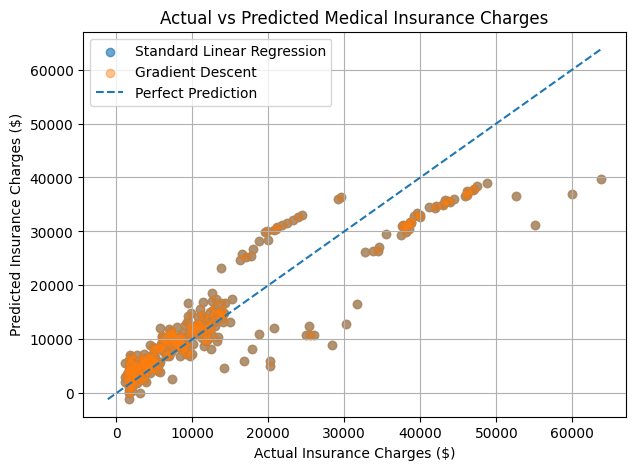

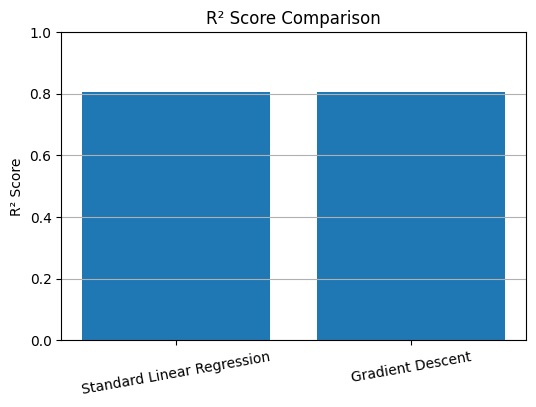

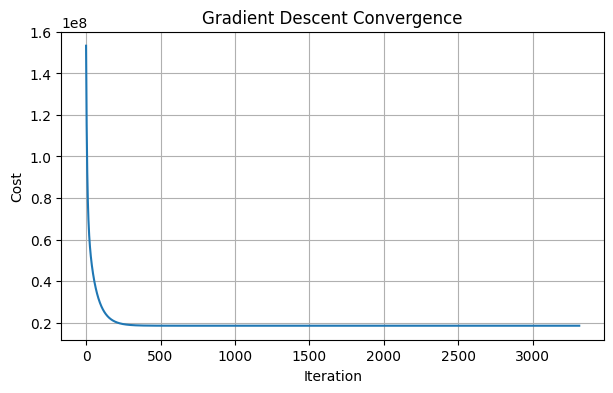

In [10]:
# 1. Actual vs predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.65, label='Standard Linear Regression')
plt.scatter(y_test_gd, y_pred_gd, alpha=0.45, label='Gradient Descent')
minimum = min(y_test.min(), y_pred_lr.min(), y_pred_gd.min())
maximum = max(y_test.max(), y_pred_lr.max(), y_pred_gd.max())
plt.plot([minimum, maximum], [minimum, maximum], '--', label='Perfect Prediction')
plt.xlabel('Actual Insurance Charges ($)')
plt.ylabel('Predicted Insurance Charges ($)')
plt.title('Actual vs Predicted Medical Insurance Charges')
plt.legend()
plt.grid(True)
plt.show()

# 2. R² comparison
plt.figure(figsize=(6, 4))
plt.bar(['Standard Linear Regression', 'Gradient Descent'], [lr_r2, gd_r2])
plt.ylabel('R² Score')
plt.title('R² Score Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.grid(axis='y')
plt.show()

# 3. Gradient Descent convergence
plt.figure(figsize=(7, 4))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.show()


## 9. Conclusion

Both Standard Linear Regression and Gradient Descent were implemented for medical insurance cost prediction. The models were evaluated using R² Score, MAE, and RMSE. Standardization of numerical features was used for the Gradient Descent implementation to improve numerical optimization and convergence.

## 10. Save the trained model

In [ ]:
import pickle

model_bundle = {
    'standard_linear_regression': linear_model,
    'gradient_descent_theta': theta,
    'gradient_descent_preprocessor': gd_preprocessor,
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'target': 'charges'
}

with open('medical_insurance_regression_models.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('Trained models saved successfully.')
